In [19]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

from maskvar.datasets import MaskLevelDatasetRandom, HQSeg44KTrainDataset
from maskvar.build_sam import sam_model_registry
from maskvar.utils import restore_normalized_image
from maskvar.utils.clicker import to_sam_format, predict_next_click, init_clicks
from maskvar.models.sam import Sam, ImageEncoderViT as SamImageEncoder, PromptEncoder, MaskDecoder
from maskvar.sam_predictor import SamPredictor


In [2]:
build_sam = sam_model_registry["vit_b"]
sam = build_sam('../ckpt/sam_vit_b_01ec64.pth')
sam = sam.eval()

In [3]:
def sam_forward(sam: Sam, image, click_list, prev_mask=None, device='cpu'):
    image_encoder: SamImageEncoder = sam.image_encoder
    prompt_encoder: PromptEncoder = sam.prompt_encoder
    mask_decoder: MaskDecoder = sam.mask_decoder
    sam.to(device)

    image = image.to(device)
    points = to_sam_format(click_list, pad_size=0, device=device)
    
    image_embedding = image_encoder(image.unsqueeze(0))

    print(image_embedding.shape)

    sparse_embedding, dense_embedding = prompt_encoder(
        points=(points[0].unsqueeze(0), points[1].unsqueeze(0)), 
        boxes=None,
        masks=None,
    )
    
    low_res_masks, iou_predictions = mask_decoder(
        image_embeddings=image_embedding,
        image_pe=prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse_embedding,
        dense_prompt_embeddings=dense_embedding,
        multimask_output=True,
    )
    return low_res_masks, image_embedding


In [4]:
def plot_mask_clicks(gt_mask, dt, click_list, pred_mask=None):
    if pred_mask is None:
        pred_mask = np.zeros_like(gt_mask)
    fig, ax = plt.subplots(1, 4, figsize=(12, 6))
    ax[0].imshow(gt_mask)
    ax[1].imshow(dt)
    ax[2].imshow(pred_mask)
    ax[3].imshow(np.logical_xor(gt_mask > 0, pred_mask > 0))

    pos_clicks = [click for click in click_list if click[2] == 1]
    neg_clicks = [click for click in click_list if click[2] == 0]

    ax[0].scatter([click[1] for click in pos_clicks], [click[0] for click in pos_clicks], color='red', marker='x')
    ax[0].scatter([click[1] for click in neg_clicks], [click[0] for click in neg_clicks], color='blue', marker='x')

    ax[3].scatter([click[1] for click in pos_clicks], [click[0] for click in pos_clicks], color='red', marker='x')
    ax[3].scatter([click[1] for click in neg_clicks], [click[0] for click in neg_clicks], color='blue', marker='x')
    return fig, ax

In [5]:
dataset = HQSeg44KTrainDataset(
    data_root='../data/sam-hq',
    img_size=(1024, 1024)
)
mask_level_dataset = MaskLevelDatasetRandom(
    dataset,
    None, 
    device='cpu',
    with_image_embed=False,
    infinite=True,
    mask_filter_thresh=0.1,
    seed=233,
    image_size_encoder=1024,
    image_size_mask=1024
)

data_iter = iter(mask_level_dataset)

In [6]:
image, _, _, gt_mask = next(data_iter)

In [7]:
restored_image = restore_normalized_image(image.permute(1, 2, 0))
clk_list, eroded_mask, dt = init_clicks(gt_mask.squeeze(0).detach().cpu().numpy(), num_random_clicks=2)

/tmp/ipykernel_898606/2222095658.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[3].imshow(np.logical_xor(gt_mask > 0, pred_mask > 0))


[(np.int64(530), np.int64(532), 1), (np.int64(675), np.int64(640), 1)]
(tensor([[532., 530.],
        [640., 675.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.],
        [  0.,   0.]]), tensor([ 1,  1, -1, -1, -1, -1, -1, -1, -1, -1], dtype=torch.int32))


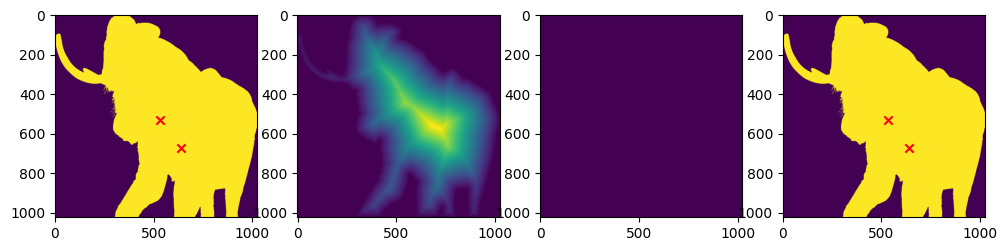

In [8]:
plot_mask_clicks(gt_mask[0], dt, clk_list, None)
print(clk_list)
print(to_sam_format(clk_list, pad_size=10))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9919196e-08..1.0].


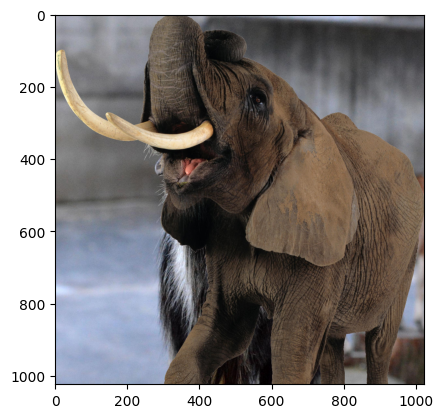

In [9]:
plt.imshow(restore_normalized_image(image.permute(1, 2, 0))/255)

In [10]:
masks, image_embedding = sam_forward(sam, image, clk_list, prev_mask=None, device='cuda')

torch.Size([1, 256, 64, 64])


In [22]:
# upscale mask to 1024x1024
prev_mask = masks[0]
high_res_mask = F.interpolate(prev_mask.unsqueeze(0), (1024, 1024), mode='bilinear', align_corners=False).squeeze(0)

In [23]:
pred_mask = high_res_mask[0].detach().cpu().numpy() > 0

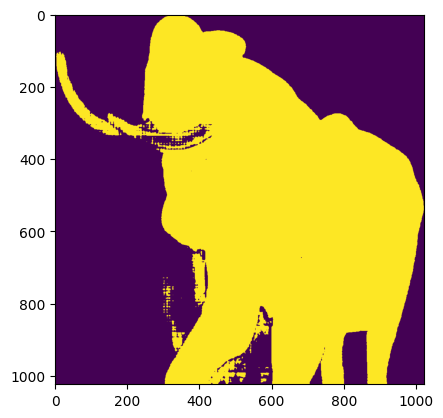

In [24]:
plt.imshow(pred_mask)

In [29]:
print(pred_mask.shape)
print(gt_mask.shape)

(1024, 1024)
torch.Size([1, 1024, 1024])


In [39]:
_, new_clk_list, not_clicked_map  = predict_next_click(
    gt_mask=gt_mask[0],
    pred_mask=pred_mask,
    click_list=clk_list,
    not_clicked_map=None,
)

In [40]:
print(new_clk_list)

[(np.int64(530), np.int64(532), 1), (np.int64(675), np.int64(640), 1), (np.int64(699), np.int64(400), 0), (np.int64(699), np.int64(400), 0), (np.int64(699), np.int64(400), 0)]


/tmp/ipykernel_898606/2222095658.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[3].imshow(np.logical_xor(gt_mask > 0, pred_mask > 0))


(<Figure size 1200x600 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

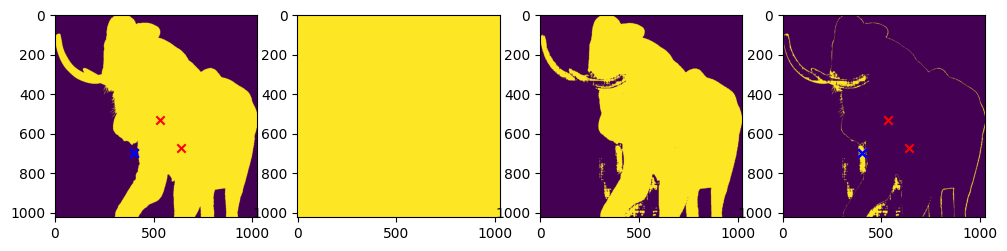

In [41]:
plot_mask_clicks(gt_mask[0], dt2, new_clk_list, pred_mask)

In [42]:
masks2, image_embedding2 = sam_forward(sam, image, new_clk_list, prev_mask=prev_mask, device='cuda')

torch.Size([1, 256, 64, 64])


In [44]:
pred_mask2 = (masks2[0] > 0).cpu().numpy()

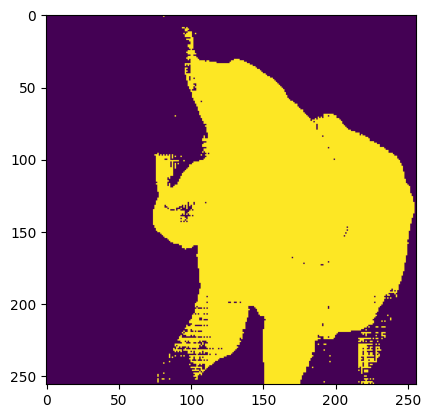

In [45]:
plt.imshow(pred_mask2[0])